In [1]:
from autstr.buildin.presentations import MSO0

# Finite Powerset Structure of (N, <) and its Connection to Büchi's MSO Logic

## Introduction

This notebook demonstrates an automatic structure for the finite powerset of natural numbers with order relations, a fundamental structure in mathematical logic and automata theory. The structure is given by:

$$\mathcal{P}_{fin}(\mathbb{N}) = (P_{fin}(\mathbb{N}), \subseteq, \text{Sing}, \text{Succ}, <_{\text{sing}}, \text{min}, \text{max})$$

where:
- $P_{fin}(\mathbb{N})$ is the set of all finite subsets of $\mathbb{N}$
- $\subseteq$ is the subset relation
- $\text{Sing}$ is the set of singleton sets $\{\{n\} \mid n \in \mathbb{N}\}$
- $\text{Succ}$ is the successor relation on singletons $\{(\{n\}, \{n+1\}) \mid n \in \mathbb{N}\}$
- $<_{\text{sing}}$ is the less-than relation on singletons $\{(\{m\}, \{n\}) \mid m < n\}$
- $\text{min}$ and $\text{max}$ are functions returning the smallest/largest element in a set

This structure is particularly significant because it is equivalent to Büchi's monadic second-order logic (MSO) on the natural numbers with the successor relation (S1S). Büchi's seminal theorem shows that the sets definable in MSO over $(\mathbb{N}, <)$ are exactly the regular sets.

## Key Connections to Büchi's Work

1. **Representation of Sets**: 
   - Finite subsets of $\mathbb{N}$ are represented as finite words over $\{0,1\}$
   - Each position in the word corresponds to a natural number
   - '1' indicates membership in the set
   - The empty set is represented by the empty word

2. **Automata-Theoretic Foundation**:
   - Büchi showed that MSO-definable sets correspond to regular languages
   - Our implementation uses finite automata to recognize relations in the structure
   - First-order definitions of operations (∩, ∪, \) mirror MSO definability

3. **Decidability**:
   - Büchi's proof established the decidability of MSO over $(\mathbb{N}, <)$
   - Our automatic presentation allows deciding first-order queries using automata operations
   - The structure is closed under first-order definitions

## Structure Highlights

Our implementation features automata for:
1. **Universe**: Recognizes valid set representations (empty set + sets ending with 1)
2. **Subset**: $X \subseteq Y$ (empty set is subset of all)
3. **Singleton**: $\{\{n\} \mid n \in \mathbb{N}\}$
4. **Successor**: $\{(\{n\}, \{n+1\}) \mid n \in \mathbb{N}\}$
5. **Less-than on singletons**: $\{(\{m\}, \{n\}) \mid m < n\}$

With first-order definitions for:
- Set equality ($X = Y$)
- Intersection ($X \cap Y$)
- Union ($X \cup Y$)
- Set difference ($X \setminus Y$)
- Minimum and maximum elements

## Why This Matters

This implementation provides a concrete computational foundation for Büchi's theoretical results, demonstrating how:
1. MSO formulas can be compiled to automata
2. Set operations correspond to automata manipulations
3. Decidability results can be made practical
4. Infinite structures can be finitely represented

The connection between automata and logic established by Büchi remains foundational in computer science, influencing areas from formal verification to database theory.

CPU times: user 28.6 ms, sys: 4.02 ms, total: 32.6 ms
Wall time: 77.1 ms


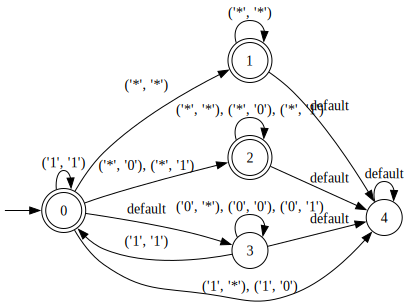

In [2]:
%%time
mso0 = MSO0()
mso0.automata["Subset"].show_diagram()

# Practical Application: Patient Selection in Clinical Trials using Automata

## Index Sets as Patient Groups in Medical Studies

Consider a clinical trial scenario where we need to select groups of patients that satisfy complex combinatorial constraints. This application demonstrates how our finite powerset structure of natural numbers (equivalent to Büchi's MSO logic) provides an elegant solution to this real-world problem.

### The Problem: K-Partitions with Regular Constraints
Imagine we have:
- A patient set P = {p₀, p₁, p₂, ..., pₙ} indexed by natural numbers
- A need to partition patients into K groups with specific constraints:
  1. **Consecutive enrollment**: Groups must consist of patients enrolled consecutively
  2. **Risk-based exclusion**: Groups must avoid certain high-risk patients
  3. **Size constraints**: Groups must have 2-5 participants
  4. **Representation requirement**: Each group must include at least one high-risk patient

### Our Automata-Theoretic Solution
Using our finite powerset structure, we can:
1. **Represent groups** as finite sets of indices
2. **Encode constraints** as automata-recognizable relations
3. **Compute valid partitions** through automata operations

```python
def find_valid_groups(patient_set, excluded, high_risk):
    # Build the automatic presentation
    ap = finite_powerset()
    
    # Define constraints via automata operations
    constraints = f"""
        Interval(X) and 
        SizeConstraint(X) and 
        forall s: (Subset(s, X) -> not Subset(s, {excluded})) and 
        exists s: (Subset(s, X) and Subset(s, {high_risk}))
    """
    
    # Evaluate constraints to get valid groups
    valid_groups_automaton = ap.evaluate(constraints)
    return extract_valid_groups(valid_groups_automaton)
```

### Key Advantages
1. **Regular Pattern Recognition**:
   - Interval constraint: `∀a,b∈X, ∀c: (a < c < b) → c∈X`
   - Encoded as automaton recognizing consecutive indices

2. **Complex Constraints**:
   ```python
   SizeConstraint = """
       exists m, M: (min(X, m) and max(X, M) and 
           (Succ(m, M) or 
            exists s1: (Succ(m, s1) and Succ(s1, M)) or 
            exists s1,s2: (Succ(m, s1) and Succ(s1, s2) and Succ(s2, M)) or 
            exists s1,s2,s3: (Succ(m, s1) and Succ(s1, s2) and Succ(s2, s3) and Succ(s3, M))
           )
   """
   ```

3. **Efficient Verification**:
   - Automata can validate groups in linear time
   - Precompiled constraints enable instant verification

### Practical Example
**Input**:
- Excluded patients E = {3,5} (high-risk)
- Required high-risk patients H = {0,2,4}

**Valid Groups**:
- {0,1}: Size 2, includes high-risk patient 0
- {1,2}: Size 2, includes high-risk patient 2
- {0,1,2}: Size 3, includes high-risk patients 0 and 2
- {4,5}: **Invalid** (contains excluded patient 5)
- {3,4}: **Invalid** (contains excluded patient 3)

### Why This Matters
This application demonstrates how Büchi's seminal work on MSO logic:
1. Provides a foundation for formalizing real-world constraints
2. Enables efficient computation through automata theory
3. Solves practical problems in healthcare analytics
4. Offers a decision procedure for complex combinatorial constraints

The connection between abstract automata theory and concrete applications like patient selection showcases the enduring power of Büchi's framework in computer science and beyond.